<table class="table table-bordered">
    <tr>
        <th style="text-align:center; width:25%"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 250px; height: 125px; "></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 2 - Sentiment Analysis Model (Problem 1)</h2><h3>AY2020/21 Semester</h3></th>
    </tr>
</table>

In [31]:
# Import the Required Packages
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GRU, LSTM
from keras.regularizers import l2
from keras.regularizers import l1
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [32]:
# Graph plotting function
def plot_graph(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

## Step 1 – Data Loading and Processing

### 1.1 Data Loading

In [33]:
# Load the emoji_dictionary
import pandas as pd
df = pd.read_csv('mapping.csv', delimiter=',')
emoji_dictionary = df.loc[:,'emoticons'].to_dict()
print(emoji_dictionary)
print('A total of: ', len(emoji_dictionary), 'Emoji Icons')
emojinp = df.to_numpy()
print(emojinp.shape)

{0: '😍', 1: '😂', 2: '📷', 3: '🔥', 4: '❤'}
A total of:  5 Emoji Icons
(5, 2)


In [34]:
# load the dataset
dat = pd.read_csv('data.txt', delimiter=',')
print(dat)

# from string import ascii_letters, digits, whitespace
# allowed = set(ascii_letters)
# allowed2 = set(digits)
# allowed = list(allowed)
# allowed.append("@")
# allowed.append(" ")
# allowed.append("#")
# allowed.append("0")
# allowed.append("1")
# allowed.append("2")
# allowed.append("3")
# allowed.append("4")
# allowed.append("5")
# allowed.append("6")
# allowed.append("7")
# allowed.append("8")
# allowed.append("9")
# print(allowed)
# dat["TEXT"] = dat["TEXT"].apply(lambda x: ''.join(["" if  i not in  allowed else i for i in x]))
# print(dat)
import string
texts = dat.loc[:,'TEXT'].values
labels = dat.loc[:,'Label'].values

def clean_text(txt):
    txt = "".join(v for v in txt if v not in string.punctuation).lower()
    txt = txt.encode("utf8").decode("ascii",'ignore')
    return txt 

texts = [clean_text(x) for x in texts]
print(len(texts))
    
# unique = []
# for sentence in texts:
#     sentence = sentence.strip()
#     sentence = sentence.lower()
#     for char in sentence:
#         if char not in unique:
#             unique.append(char)

# print(sorted(unique))

                                                    TEXT  Label
0      Been friends since 7th grade. Look at us now w...      0
1      This is what it looks like when someone loves ...      1
2      RT @user this white family was invited to a Bl...      1
3      Westenders @user #LAZzNation @ Weston, Toronto...      2
4      Maxwell heads home @ Summa Akron City Hospital...      0
...                                                  ...    ...
42541         The sky tonight?! @ New York, New York\r\n      0
42542  It’s Universal Studios time! ️I’m so happy, I ...      4
42543  Meet Olive. Our new #GreatDane ️ ️ ️#DogsOfDen...      4
42544  "I talk gray, I don't keep it white and black"...      2
42545  When his baby comes to visit. ️#cheflife #chef...      4

[42546 rows x 2 columns]
42546


In [35]:
# Check the maximum length of texts
max_len = -1
for example in texts:
    if len(example.split()) > max_len:
        max_len = len(example.split())
        
print('the maximum length of the text inputs is ', max_len) #34 unchanged

the maximum length of the text inputs is  33


### 1.2 Data Processing


In [36]:
# Convert the texts and labels into numeric tensors

maxlen = 33
training_samples = len(texts)
# validation_samples = 5000 #math.floor(training_samples * 0.2)
max_words = 30000 # unique words in vocab list

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post')

labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

Found 56213 unique tokens.
Shape of data tensor: (42546, 33)
Shape of label tensor: (42546,)


### 1.3 Data Sampling

In [37]:
# Split the X & y into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state = 24)
# Refer the report Appendix
# Please enter the random_state assigned to your group
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (34036, 33)
y_train (34036,)
X_test (8510, 33)
y_test (8510,)


## Step 2 – Develop a Sentiment Analysis Model

### Model #1 (Replicate as necessary for other models)

In [40]:
# Build the Model 1
model = Sequential()
model.add(Embedding(max_words, 64, input_length=maxlen))
model.add(LSTM(32, return_sequences=True, dropout=(0.3)))
model.add(LSTM(32, kernel_regularizer=l2(0.0005), return_sequences=True, dropout=(0.3)))
model.add(LSTM(16))
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_9 (Embedding)      (None, 33, 64)            1920000   
_________________________________________________________________
lstm_19 (LSTM)               (None, 33, 32)            12416     
_________________________________________________________________
lstm_20 (LSTM)               (None, 33, 32)            8320      
_________________________________________________________________
lstm_21 (LSTM)               (None, 16)                3136      
_________________________________________________________________
dropout_5 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_9 (Dense)              (None, 5)                 85        
Total params: 1,943,957
Trainable params: 1,943,957
Non-trainable params: 0
____________________________________________

In [41]:
# Train the Model 
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0015),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=128,
                    validation_split=0.2)

Train on 27228 samples, validate on 6808 samples
Epoch 1/25
27228/27228 [==============================] - 47s 2ms/sample - loss: 1.3674 - acc: 0.4483 - val_loss: 1.2674 - val_acc: 0.4897
Epoch 2/25
27228/27228 [==============================] - 35s 1ms/sample - loss: 1.1931 - acc: 0.5338 - val_loss: 1.1723 - val_acc: 0.5454
Epoch 3/25
27228/27228 [==============================] - 38s 1ms/sample - loss: 1.0770 - acc: 0.5778 - val_loss: 1.1629 - val_acc: 0.5408
Epoch 4/25
27228/27228 [==============================] - 35s 1ms/sample - loss: 0.9936 - acc: 0.6142 - val_loss: 1.1702 - val_acc: 0.5372
Epoch 5/25
27228/27228 [==============================] - 36s 1ms/sample - loss: 0.9175 - acc: 0.6467 - val_loss: 1.1923 - val_acc: 0.5162
Epoch 6/25
27228/27228 [==============================] - 37s 1ms/sample - loss: 0.8566 - acc: 0.6860 - val_loss: 1.1728 - val_acc: 0.5568
Epoch 7/25
27228/27228 [==============================] - 38s 1ms/sample - loss: 0.7933 - acc: 0.7228 - val_loss: 1.1

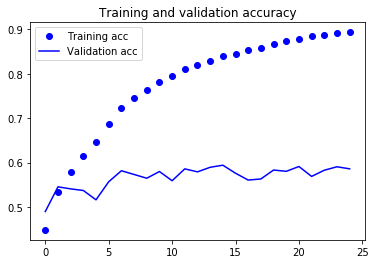

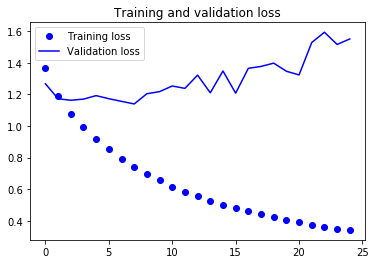

In [42]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history)

In [ ]:
# Save the Model
model.save('text_model_1.h5')

## Step 3 – Evaluate the Model using Testing Data 

In [ ]:
# Model (replicate where necessary for other models)
model.load_weights('text_model_1.h5')


In [ ]:
# Test the Model
model.load_weights('text_model_1.h5')

testResult = model.evaluate(X_test, y_test)
print(testResult)

In [ ]:
# Save the Best Model
model.save('text_model_best.h5')

## Step 4 – Use the Best Model to make prediction

In [ ]:
model.load_weights('text_model_best.h5')

In [ ]:
# takes the user input
# text_input = np.array([input()])
testList = []
userInput = input("Please enter an input: ")
testList.append(userInput)

In [ ]:
# convert the user input into numeric tensor
seq = tokenizer.texts_to_sequences(testList)
test = pad_sequences(seq, maxlen=maxlen, padding="post")

In [ ]:
# show the model output using predict function
resultTest = model.predict_classes(test)
for emoji in emoji_dictionary:
    if resultTest == emoji:
        print(emoji_dictionary.get(emoji))